Before running this notbook, please run fittinglikelihood_trinucleotidemodel.ipynb

In [1]:
import cogent3
from cogent3 import get_app
import matplotlib.pyplot as plt
import paths
import libs
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

import pickle

import trinuc_models as trinucs # this module must be in the same directory as this notebook

## Intergenic Ancestral Repeats (IGAR)

In [2]:
#Load IGAR likelihood model
with open("fitted_models/likelihood_IGAR.pickle", mode = "rb") as infile: 
    result_IGAR=pickle.load(infile)

humanENS_IGAR_cpg = result_IGAR.lf.get_scaled_lengths("CpG")['Human']
humanENS_IGAR_notcpg = result_IGAR.lf.get_scaled_lengths("notCpG")['Human']

print(humanENS_IGAR_cpg)
print(humanENS_IGAR_notcpg)

0.017293566499792096
0.00714627944957059


## CDS

In [9]:
#Getting cds ENS
#Load cds likelihood model
with open("fitted_models/likelihood_cds.pickle", mode = "rb") as infile: 
    result_cds=pickle.load(infile)

humanENS_cds_cpg = result_cds.lf.get_scaled_lengths("CpG")['Human']
humanENS_cds_notcpg = result_cds.lf.get_scaled_lengths("notCpG")['Human']

In [6]:
#Setting up the app for reading cds sequences
loader_cds = get_app("load_aligned", moltype="dna")   
omit_degs_cds = get_app("omit_degenerates", moltype="dna", motif_length=3)
concat = get_app("concat", moltype="dna")

#create a concatenated alignment with all coding positions
cds_process = loader_cds + omit_degs_cds

In [10]:
folder_in = paths.DATA_APES114 + 'cds/codon_aligned'
in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')

#nonconcat_cds = [r for r in cds_process.as_completed(in_dstore[:], parallel=True) if r]
# This clear progress bar and avoids errors
#tqdm._instances.clear()

#cds_alns = concat(nonconcat_cds)
#cds_alns.source = "cds_alignments"

new_lf = trinucs.modified_lf_cds(result_IGAR.lf, result_cds.lf)
#new_lf.set_alignment(cds_alns, motif_pseudocount=1e-12)

humanENS_cds_cpg_IGARQ = new_lf.get_scaled_lengths("CpG")["Human"]
humanENS_cds_notcpg_IGARQ = new_lf.get_scaled_lengths("notCpG")["Human"]

print(humanENS_cds_cpg)
print(humanENS_cds_cpg_IGARQ)

print(humanENS_cds_notcpg)
print(humanENS_cds_notcpg_IGARQ)

0.006180909138877479
0.00946306693273758
0.00719814402154556
0.0039159862276854545


In [13]:
new_lf.get_param_rules()

[{'par_name': 'mprobs',
  'init': {'TTT': np.float64(0.011920994264982348),
   'TTC': np.float64(0.023110084928690967),
   'TTA': np.float64(0.0032274235479521946),
   'TTG': np.float64(0.009170812048030318),
   'TCT': np.float64(0.010990337075632448),
   'TCC': np.float64(0.020787260513824332),
   'TCA': np.float64(0.008620371904048959),
   'TCG': np.float64(0.0061976785162404895),
   'TAT': np.float64(0.007656616564594226),
   'TAC': np.float64(0.017702609481431698),
   'TAA': np.float64(1.000002000094016e-06),
   'TAG': np.float64(1.000002000094016e-06),
   'TGT': np.float64(0.0072296070692393416),
   'TGC': np.float64(0.013987074099422344),
   'TGA': np.float64(1.000002000094016e-06),
   'TGG': np.float64(0.012713496653477041),
   'CTT': np.float64(0.0085745748899937),
   'CTC': np.float64(0.023275652726756656),
   'CTA': np.float64(0.004674572530582352),
   'CTG': np.float64(0.053274983573470554),
   'CCT': np.float64(0.01576199779261765),
   'CCC': np.float64(0.028123265149489988

In [15]:
result_IGAR.lf.get_param_rules()

[{'par_name': 'mprobs',
  'init': {'TTT': np.float64(0.03064609138670596),
   'TTC': np.float64(0.015787225441520496),
   'TTA': np.float64(0.014582570683784168),
   'TTG': np.float64(0.018297200022532874),
   'TCT': np.float64(0.02063685286383953),
   'TCC': np.float64(0.017513588585801734),
   'TCA': np.float64(0.019684761397329314),
   'TCG': np.float64(0.003639930295952387),
   'TAT': np.float64(0.0127681199110598),
   'TAC': np.float64(0.009624617081149681),
   'TAA': np.float64(0.014326192925519234),
   'TAG': np.float64(0.011229162544676088),
   'TGT': np.float64(0.01799002092803186),
   'TGC': np.float64(0.016616125287523025),
   'TGA': np.float64(0.019955783612426996),
   'TGG': np.float64(0.02339621936069434),
   'CTT': np.float64(0.016586280430837732),
   'CTC': np.float64(0.022170079862523055),
   'CTA': np.float64(0.011244771227696019),
   'CTG': np.float64(0.025399491854618674),
   'CCT': np.float64(0.02187510600041866),
   'CCC': np.float64(0.016565160876338),
   'CCA': 

In [16]:
result_cds.lf.get_param_rules()

[{'par_name': 'mprobs',
  'init': {'TTT': np.float64(0.011920757193241366),
   'TTC': np.float64(0.023110564005335787),
   'TTA': np.float64(0.0032266300514915483),
   'TTG': np.float64(0.009170398953177672),
   'TCT': np.float64(0.01099004043795676),
   'TCC': np.float64(0.02078759092003603),
   'TCA': np.float64(0.00861992357873546),
   'TCG': np.float64(0.006197075128463818),
   'TAT': np.float64(0.007656106554926618),
   'TAC': np.float64(0.017702742457135056),
   'TGT': np.float64(0.007229069729186271),
   'TGC': np.float64(0.013986969265392437),
   'TGG': np.float64(0.012713310305188333),
   'CTT': np.float64(0.008574123633480637),
   'CTC': np.float64(0.02327614240042986),
   'CTA': np.float64(0.004673871657681481),
   'CTG': np.float64(0.05327739332921358),
   'CCT': np.float64(0.01576200656109361),
   'CCC': np.float64(0.028124065090540218),
   'CCA': np.float64(0.015107650405856397),
   'CCG': np.float64(0.010632898509549613),
   'CAT': np.float64(0.007366189587694894),
   'C

# Non cds regions

In [6]:
#Setting up the app for reading noncds sequences
#rename_noncds eliminates files that do not contain Gorilla, Human and Chimp sequences or that has duplicates.
loader = get_app("load_aligned", moltype="dna")
#Because I am using a trinucleotide I need to omit degenerates using motif 3
omit_degs_noncds = get_app("omit_degenerates", moltype="dna", motif_length=3)
rename_noncds = libs.renamer_noncds_aligned()
concat = get_app("concat", moltype="dna")

noncds_app = loader + omit_degs_noncds + rename_noncds

## Introns

In [7]:
#Getting cds ENS
#Load IGAR likelihood model
with open("fitted_models/likelihood_introns.pickle", mode = "rb") as infile: 
    result_introns = pickle.load(infile)

humanENS_introns_cpg = result_introns.lf.get_scaled_lengths("CpG")['Human']
humanENS_introns_notcpg = result_introns.lf.get_scaled_lengths("notCpG")['Human']

In [8]:
folder_in = paths.DATA_APES114 + 'introns/noUTRs/'
in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')

# noncds_app is defined on the Intergenic Ancestral Repeat section
nonconcat_introns = [r for r in noncds_app.as_completed(in_dstore[:], parallel=True) if r]
# This clear progress bar and avoids errors
tqdm._instances.clear()

alns_introns = concat(nonconcat_introns)
alns_introns.source = "introns_alignments"

new_lf = trinucs.modified_lf(result_IGAR.lf)
new_lf.set_alignment(alns_introns, motif_pseudocount=1e-12)

humanENS_introns_cpg_IGARQ = new_lf.get_scaled_lengths("CpG")["Human"]
humanENS_introns_notcpg_IGARQ = new_lf.get_scaled_lengths("notCpG")["Human"]

print(humanENS_introns_cpg)
print(humanENS_introns_notcpg)

print(humanENS_introns_cpg_IGARQ)
print(humanENS_introns_notcpg_IGARQ)

   0%|          |00:00<?

0.013049395895875704
0.005044777044407502
0.01724232461774548
0.007197521331617205


## 5' UTR

In [9]:
#Getting cds ENS
#Load IGAR likelihood model
with open("fitted_models/likelihood_5UTR.pickle", mode = "rb") as infile: 
    result_5UTR = pickle.load(infile)

humanENS_5UTR_cpg = result_5UTR.lf.get_scaled_lengths("CpG")['Human']
humanENS_5UTR_notcpg = result_5UTR.lf.get_scaled_lengths("notCpG")['Human']

In [10]:
folder_in = paths.DATA_APES114 + 'introns/5UTR/'
in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')

# noncds_app is defined on the Intergenic Ancestral Repeat section
nonconcat_5UTR = [r for r in noncds_app.as_completed(in_dstore[:], parallel=True) if r]
# This clear progress bar and avoids errors
tqdm._instances.clear()

alns_5UTR = concat(nonconcat_5UTR)
alns_5UTR.source = "5UTR_alignments"

new_lf = trinucs.modified_lf(result_IGAR.lf)
new_lf.set_alignment(alns_5UTR, motif_pseudocount=1e-12)

humanENS_5UTR_cpg_IGARQ = new_lf.get_scaled_lengths("CpG")["Human"]
humanENS_5UTR_notcpg_IGARQ = new_lf.get_scaled_lengths("notCpG")["Human"]

print(humanENS_5UTR_cpg)
print(humanENS_5UTR_notcpg)

print(humanENS_5UTR_cpg_IGARQ)
print(humanENS_5UTR_notcpg_IGARQ)

   0%|          |00:00<?

0.011468500311325906
0.0046553475124153434
0.017198585297904023
0.007241260651458656


## 3' UTR

In [11]:
#Getting cds ENS
#Load IGAR likelihood model
with open("fitted_models/likelihood_3UTR.pickle", mode = "rb") as infile: 
    result_3UTR = pickle.load(infile)

humanENS_3UTR_cpg = result_3UTR.lf.get_scaled_lengths("CpG")['Human']
humanENS_3UTR_notcpg = result_3UTR.lf.get_scaled_lengths("notCpG")['Human']

In [12]:
folder_in = paths.DATA_APES114 + 'introns/3UTR/'
in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')

# noncds_app is defined on the Intergenic Ancestral Repeat section
nonconcat_3UTR = [r for r in noncds_app.as_completed(in_dstore[:], parallel=True) if r]
# This clear progress bar and avoids errors
tqdm._instances.clear()

alns_3UTR = concat(nonconcat_3UTR)
alns_3UTR.source = "3UTR_alignments"

new_lf = trinucs.modified_lf(result_IGAR.lf)
new_lf.set_alignment(alns_3UTR, motif_pseudocount=1e-12)

humanENS_3UTR_cpg_IGARQ = new_lf.get_scaled_lengths("CpG")["Human"]
humanENS_3UTR_notcpg_IGARQ = new_lf.get_scaled_lengths("notCpG")["Human"]

print(humanENS_3UTR_cpg)
print(humanENS_3UTR_notcpg)

print(humanENS_3UTR_cpg_IGARQ)
print(humanENS_3UTR_notcpg_IGARQ)

   0%|          |00:00<?

0.011988575827754732
0.0049692743119904605
0.017168805171036333
0.007271040778326354


## Introns Ancestral Repeats (IntronAR)

In [13]:
#Getting cds ENS
#Load IGAR likelihood model
with open("fitted_models/likelihood_intronsAR.pickle", mode = "rb") as infile: 
    result_intronsAR = pickle.load(infile)

humanENS_intronsAR_cpg = result_intronsAR.lf.get_scaled_lengths("CpG")['Human']
humanENS_intronsAR_notcpg = result_intronsAR.lf.get_scaled_lengths("notCpG")['Human']

In [14]:
folder_in = paths.DATA_APES114 + 'intronsAR'
in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')

# noncds_app is defined on the Intergenic Ancestral Repeat section
nonconcat_intronsAR = [r for r in noncds_app.as_completed(in_dstore[:], parallel=True) if r]
# This clear progress bar and avoids errors
tqdm._instances.clear()

alns_intronsAR = concat(nonconcat_intronsAR)
alns_intronsAR.source = "intronsAR_alignments"

new_lf = trinucs.modified_lf(result_IGAR.lf)
new_lf.set_alignment(alns_intronsAR, motif_pseudocount=1e-12)

humanENS_intronsAR_cpg_IGARQ = new_lf.get_scaled_lengths("CpG")["Human"]
humanENS_intronsAR_notcpg_IGARQ = new_lf.get_scaled_lengths("notCpG")["Human"]

print(humanENS_intronsAR_cpg)
print(humanENS_intronsAR_notcpg)

print(humanENS_intronsAR_cpg_IGARQ)
print(humanENS_intronsAR_notcpg_IGARQ)

   0%|          |00:00<?

Exception ignored in: <function tqdm.__del__ at 0x7f4a0de56840>
Traceback (most recent call last):
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 282, in close
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/tqdm/notebook.py", line 171, in display
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 716, in __set__
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 706, in set
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/traitlets/traitlets.py", line 1513, in _notify_trait
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/site-packages/ipywidgets/widgets/widget.py", line 700, in notify_change
  File "/home/u12/uliseshmc/.conda/envs/delme/lib/python3.13/si

0.014965702225298035
0.0057244218002615475
0.01727404046011492
0.007165805489247768


## Intergenic distal (5kb distal from transcript)

In [15]:
#Getting cds ENS
#Load IGAR likelihood model
with open("fitted_models/likelihood_distalIG.pickle", mode = "rb") as infile: 
    result_distalIG = pickle.load(infile)

humanENS_distalIG_cpg = result_distalIG.lf.get_scaled_lengths("CpG")['Human']
humanENS_distalIG_notcpg = result_distalIG.lf.get_scaled_lengths("notCpG")['Human']

In [16]:
folder_in = paths.DATA_APES114 + 'distal_IG/'
in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')

# noncds_app is defined on the Intergenic Ancestral Repeat section
nonconcat_distalIG = [r for r in noncds_app.as_completed(in_dstore[:], parallel=True) if r]
# This clear progress bar and avoids errors
tqdm._instances.clear()

alns_distalIG = concat(nonconcat_distalIG)
alns_distalIG.source = "distalIG_alignments"

new_lf = trinucs.modified_lf(result_IGAR.lf)
new_lf.set_alignment(alns_distalIG, motif_pseudocount=1e-12)

humanENS_distalIG_cpg_IGARQ = new_lf.get_scaled_lengths("CpG")["Human"]
humanENS_distalIG_notcpg_IGARQ = new_lf.get_scaled_lengths("notCpG")["Human"]

print(humanENS_distalIG_cpg)
print(humanENS_distalIG_notcpg)

print(humanENS_distalIG_cpg_IGARQ)
print(humanENS_distalIG_notcpg_IGARQ)

   0%|          |00:00<?

0.016167138914977962
0.006305653304005645
0.017260459432496933
0.00717938651686576


## Intergenic proximal 5' (5kb proximal from transcript start)

In [17]:
#Getting cds ENS
#Load IGAR likelihood model
with open("fitted_models/likelihood_proximal5IG.pickle", mode = "rb") as infile: 
    result_proximal5IG = pickle.load(infile)

humanENS_proximal5IG_cpg = result_proximal5IG.lf.get_scaled_lengths("CpG")['Human']
humanENS_proximal5IG_notcpg = result_proximal5IG.lf.get_scaled_lengths("notCpG")['Human']

In [18]:
folder_in = paths.DATA_APES114 + 'proximal5_IG/'
in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')

# noncds_app is defined on the Intergenic Ancestral Repeat section
nonconcat_proximal5IG = [r for r in noncds_app.as_completed(in_dstore[:], parallel=True) if r]
# This clear progress bar and avoids errors
tqdm._instances.clear()

alns_proximal5IG = concat(nonconcat_proximal5IG)
alns_proximal5IG.source = "proximal5IG_alignments"

new_lf = trinucs.modified_lf(result_IGAR.lf)
new_lf.set_alignment(alns_proximal5IG, motif_pseudocount=1e-12)

humanENS_proximal5IG_cpg_IGARQ = new_lf.get_scaled_lengths("CpG")["Human"]
humanENS_proximal5IG_notcpg_IGARQ = new_lf.get_scaled_lengths("notCpG")["Human"]

print(humanENS_proximal5IG_cpg)
print(humanENS_proximal5IG_notcpg)

print(humanENS_proximal5IG_cpg_IGARQ)
print(humanENS_proximal5IG_notcpg_IGARQ)

   0%|          |00:00<?

0.014994044586931045
0.005861884413317872
0.017198155145895216
0.007241690803467459


## Intergenic proximal 3' (5kb proximal from transcript end)

In [24]:
#Getting cds ENS
#Load IGAR likelihood model
with open("fitted_models/likelihood_proximal3IG.pickle", mode = "rb") as infile: 
    result_proximal3IG = pickle.load(infile)

humanENS_proximal3IG_cpg = result_proximal3IG.lf.get_scaled_lengths("CpG")['Human']
humanENS_proximal3IG_notcpg = result_proximal3IG.lf.get_scaled_lengths("notCpG")['Human']

In [25]:
folder_in = paths.DATA_APES114 + 'proximal3_IG/'
in_dstore = cogent3.open_data_store(folder_in, suffix='fa', mode='r')

# noncds_app is defined on the Intergenic Ancestral Repeat section
nonconcat_proximal3IG = [r for r in noncds_app.as_completed(in_dstore[:], parallel=True) if r]
# This clear progress bar and avoids errors
tqdm._instances.clear()

alns_proximal3IG = concat(nonconcat_proximal3IG)
alns_proximal3IG.source = "proximal3IG_alignments"

new_lf = trinucs.modified_lf(result_IGAR.lf)
new_lf.set_alignment(alns_proximal3IG, motif_pseudocount=1e-12)

humanENS_proximal3IG_cpg_IGARQ = new_lf.get_scaled_lengths("CpG")["Human"]
humanENS_proximal3IG_notcpg_IGARQ = new_lf.get_scaled_lengths("notCpG")["Human"]

print(humanENS_proximal3IG_cpg)
print(humanENS_proximal3IG_notcpg)

print(humanENS_proximal3IG_cpg_IGARQ)
print(humanENS_proximal3IG_notcpg_IGARQ)

   0%|          |00:00<?

0.014589894359655192
0.005737675495558321
0.017189074746995377
0.007250771202367307


Text(0, 0.5, 'ENS')

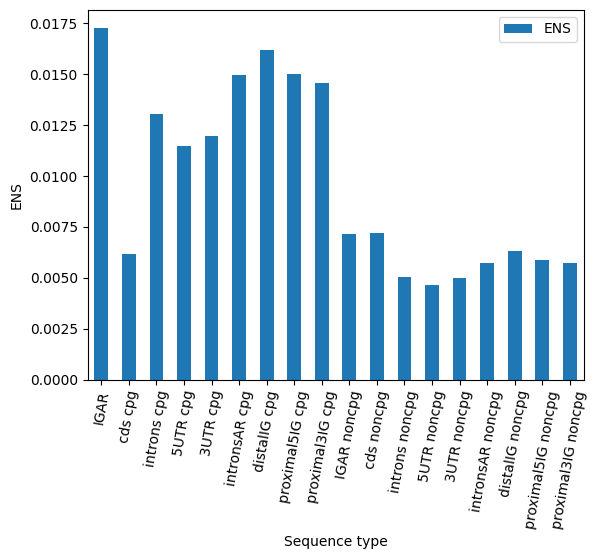

In [40]:
ENS_data = pd.DataFrame([
    ['IGAR', humanENS_IGAR_cpg],
    ['cds cpg', humanENS_cds_cpg],
    ['introns cpg', humanENS_introns_cpg],
    ['5UTR cpg', humanENS_5UTR_cpg],
    ['3UTR cpg', humanENS_3UTR_cpg],
    ['intronsAR cpg', humanENS_intronsAR_cpg],
    ['distalIG cpg', humanENS_distalIG_cpg],
    ['proximal5IG cpg', humanENS_proximal5IG_cpg],
    ['proximal3IG cpg', humanENS_proximal3IG_cpg],
    ['IGAR noncpg', humanENS_IGAR_notcpg],
    ['cds noncpg', humanENS_cds_notcpg],
    ['introns noncpg', humanENS_introns_notcpg],
    ['5UTR noncpg', humanENS_5UTR_notcpg],
    ['3UTR noncpg', humanENS_3UTR_notcpg],
    ['intronsAR noncpg', humanENS_intronsAR_notcpg],
    ['distalIG noncpg', humanENS_distalIG_notcpg],
    ['proximal5IG noncpg', humanENS_proximal5IG_notcpg],
    ['proximal3IG noncpg', humanENS_proximal3IG_notcpg]
    ],
    columns = ['Sequence type', 'ENS'])

ENS_data.plot(
    x='Sequence type',
    kind = 'bar',
    rot=80)
plt.ylabel('ENS')

In [33]:
def calculate_constraint(ENS, ENSneutral):
    return (ENSneutral - ENS)/ENSneutral 

Text(0, 0.5, 'Constraint')

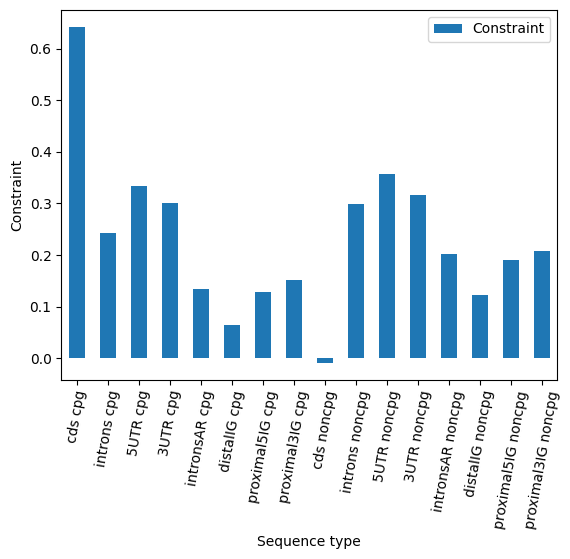

In [36]:
Constraint_data = pd.DataFrame([
    ['cds cpg', calculate_constraint(humanENS_cds_cpg, humanENS_cds_cpg_IGARQ)],
    ['introns cpg', calculate_constraint(humanENS_introns_cpg, humanENS_introns_cpg_IGARQ)],
    ['5UTR cpg', calculate_constraint(humanENS_5UTR_cpg, humanENS_5UTR_cpg_IGARQ)],
    ['3UTR cpg', calculate_constraint(humanENS_3UTR_cpg, humanENS_3UTR_cpg_IGARQ)],
    ['intronsAR cpg', calculate_constraint(humanENS_intronsAR_cpg, humanENS_intronsAR_cpg_IGARQ)],
    ['distalIG cpg', calculate_constraint(humanENS_distalIG_cpg, humanENS_distalIG_cpg_IGARQ)],
    ['proximal5IG cpg', calculate_constraint(humanENS_proximal5IG_cpg, humanENS_proximal5IG_cpg_IGARQ)],
    ['proximal3IG cpg', calculate_constraint(humanENS_proximal3IG_cpg, humanENS_proximal3IG_cpg_IGARQ)],
    ['cds noncpg', calculate_constraint(humanENS_cds_notcpg, humanENS_cds_notcpg_IGARQ)],
    ['introns noncpg', calculate_constraint(humanENS_introns_notcpg, humanENS_introns_notcpg_IGARQ)],
    ['5UTR noncpg', calculate_constraint(humanENS_5UTR_notcpg, humanENS_5UTR_notcpg_IGARQ)],
    ['3UTR noncpg', calculate_constraint(humanENS_3UTR_notcpg, humanENS_3UTR_notcpg_IGARQ)],
    ['intronsAR noncpg', calculate_constraint(humanENS_intronsAR_notcpg, humanENS_intronsAR_notcpg_IGARQ)],
    ['distalIG noncpg', calculate_constraint(humanENS_distalIG_notcpg, humanENS_distalIG_notcpg_IGARQ)],
    ['proximal5IG noncpg', calculate_constraint(humanENS_proximal5IG_notcpg, humanENS_proximal5IG_notcpg_IGARQ)],
    ['proximal3IG noncpg', calculate_constraint(humanENS_proximal3IG_notcpg, humanENS_proximal3IG_notcpg_IGARQ)]
    ],
    columns = ['Sequence type', 'Constraint'])

Constraint_data.plot(
    x='Sequence type',
    kind = 'bar',
    rot=80)
plt.ylabel('Constraint')

In [ ]:
Constraint_data.to_csv("Output_data/Constraint_perregion.csv", index=False)
Constraint_data

In [ ]:
Every chromosome independently